# Project 1 — Image Registration and Quality Assessment

## Goal
Evaluate the reliability of image registration
after a controlled spatial transformation and assess
the impact of registration errors on downstream
spatial analysis.

## Data source
Kather Texture 2016 dataset — H&E stained colorectal tissue patches
Source: Zenodo https://doi.org/10.5281/zenodo.1214456
License: CC BY 4.0

## Background
Spatial data quality assessment principles from geodesy,
photogrammetry and metrology applied to biological
image registration.

In [5]:
import os
os.makedirs("data", exist_ok=True)
if os.path.exists("tumor_patch.tif"):
    os.rename("tumor_patch.tif", "data/tumor_patch.tif")

## Step 1 — Load Input Image

The input image is taken from the Kather Texture 2016 dataset — H&E stained colorectal tissue patches, available at Zenodo. Source: https://doi.org/10.5281/zenodo.53169

Image shape: (150, 150, 3)
Data type: uint8
Min value: 4 Max value: 250


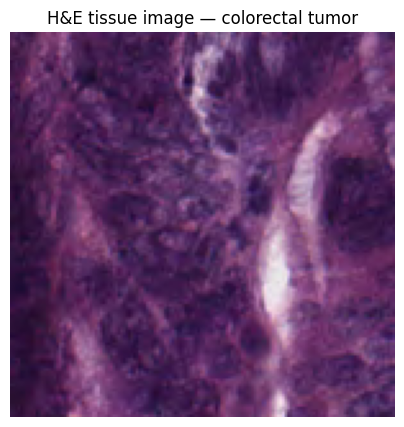

In [6]:
# Import image processing library
from skimage import io
import matplotlib.pyplot as plt

# Load the image into a NumPy array
image = io.imread("data/tumor_patch.tif")

# Display image dimensions (height, width, channels)
print("Image shape:", image.shape)

# Display data type of pixel values
print("Data type:", image.dtype)

# Display range of pixel values
print("Min value:", image.min(), "Max value:", image.max())

# Display the H&E tissue image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("H&E tissue image — colorectal tumor")
plt.axis('off')
plt.show()

## Step 2 — Channel Analysis

Before registration, we inspect the image channels to identify reliable spatial landmarks. This step is analogous to reconnaissance in geodesy and ground control point selection in photogrammetry. The image is treated not as a picture, but as a spatial raster composed of multiple information layers. The goal is to find stable and distinguishable structures that can later be used for image alignment and registration quality assessment.

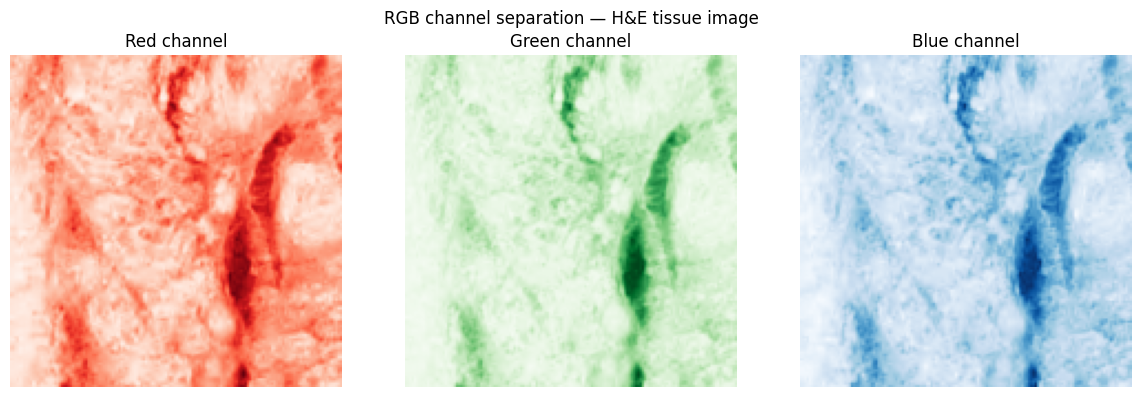

In [7]:
# Separate and display individual RGB channels of the tissue image
import matplotlib.pyplot as plt

# Extract each channel separately
red_channel   = image[:, :, 0]  # R — dominant in eosin-stained structures
green_channel = image[:, :, 1]  # G — mixed signal
blue_channel  = image[:, :, 2]  # B — nuclei-rich structures often more visible

# Display all three channels side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title('Red channel')
axes[0].axis('off')

axes[1].imshow(green_channel, cmap='Greens')
axes[1].set_title('Green channel')
axes[1].axis('off')

axes[2].imshow(blue_channel, cmap='Blues')
axes[2].set_title('Blue channel')
axes[2].axis('off')

plt.suptitle('RGB channel separation — H&E tissue image')
plt.tight_layout()
plt.show()

### Observations

The image is stored as a three-channel RGB raster of 150×150 pixels. All three channels contain similar spatial information. The main image structures remain visible and distinguishable across all channels. Visual differences between channels are moderate for this image. Several high-contrast structures may potentially serve as candidates for registration landmarks. A more detailed assessment of these structures will be performed at the control point selection stage.

### Numerical Channel Analysis

Visual inspection helps identify structures, but does not allow quantitative comparison of channels. In geodesy and metrology, observation is always supplemented by measurement. Therefore, after visual analysis, we proceed to numerical evaluation of the channels. The goal is to determine how pixel value distributions differ across channels and which channels potentially contain more distinct spatial information for subsequent registration.

In [8]:
# Compute basic statistics for each channel to quantify spatial information content
import numpy as np

# Calculate statistics for each channel
stats = {
    'Red': [
        red_channel.min(),
        red_channel.max(),
        round(red_channel.mean(), 2),
        round(red_channel.std(), 2)
    ],
    'Green': [
        green_channel.min(),
        green_channel.max(),
        round(green_channel.mean(), 2),
        round(green_channel.std(), 2)
    ],
    'Blue': [
        blue_channel.min(),
        blue_channel.max(),
        round(blue_channel.mean(), 2),
        round(blue_channel.std(), 2)
    ]
}

# Display results as a summary table
print(f"{'Channel':<10} {'Min':>6} {'Max':>6} {'Mean':>8} {'Std':>8}")
print("-" * 42)
for channel, values in stats.items():
    print(f"{channel:<10} {values[0]:>6} {values[1]:>6} {values[2]:>8.2f} {values[3]:>8.2f}")

Channel       Min    Max     Mean      Std
------------------------------------------
Red            23    250    93.24    36.49
Green           4    233    50.36    32.85
Blue           43    240   100.45    30.39


### Observations

All three channels show similar value ranges and comparable standard deviation values (30–36). Quantitative analysis confirms the visual observation: differences between channels are present but not pronounced. The red channel shows the highest pixel value spread, however at this stage this is not a basis for channel selection for registration.

## Step 3 — Controlled Shift

Controlled shift is the first spatial transformation in the project.
Shifting an image is not moving a picture on a screen — it is a change
of value coordinates within a fixed raster grid. In metrology, this
approach is analogous to calibration against a reference standard: we
know the correct displacement in advance and can verify how accurately
registration will recover it.

### Experiment Parameters

For the first experiment, a shift of 10 pixels is applied. This
displacement is large enough to be detectable and measurable, while
preserving most of the shared spatial information in the image.

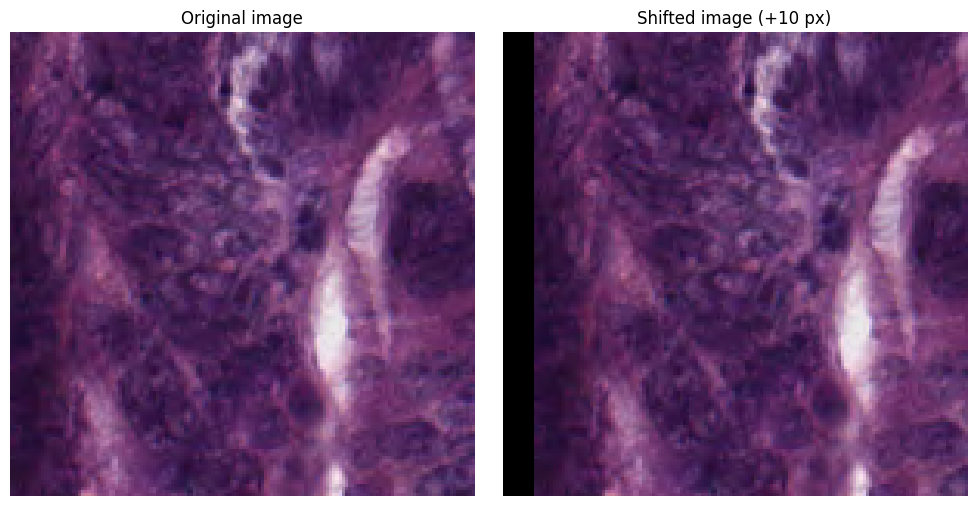

In [9]:
# Apply a controlled shift of 10 pixels to the right
# This is a manual array shift — makes the mechanics visible
import numpy as np
import matplotlib.pyplot as plt

# Known shift value — ground truth for later validation
shift_x = 10  # pixels to the right

# Create an empty array of the same size filled with zeros
# Zeros will appear as black pixels on the left side
shifted_image = np.zeros_like(image)

# Place the original image content shifted to the right
# Left side (columns 0 to shift_x) remains zero — black border
# Right side (last shift_x columns) of original is lost — cropped
shifted_image[:, shift_x:, :] = image[:, :-shift_x, :]

# Display original and shifted images side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(shifted_image)
axes[1].set_title(f"Shifted image (+{shift_x} px)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Observations

A controlled shift of 10 pixels to the right was successfully applied. The shifted image shows a black border of 10 pixels on the left side — a region of zero values introduced by the shift. Both images retain the same dimensions (150×150 pixels), confirming that the shift occurred within a fixed raster grid. The known displacement serves as ground truth for evaluating registration accuracy in subsequent steps.

## Step 4 — Registration

Registration is the process of finding a spatial transformation that
aligns two images. In photogrammetry, an analogous task arises when
aligning overlapping images, where a transformation must be determined
that maps one image into the coordinate system of another.

In this experiment, the algorithm does not know the true displacement
and must determine it automatically from the image data. Since the
displacement is known in advance, the registration result can be
compared against the reference value and the accuracy of the method
can be assessed.

In [10]:
# Estimate the displacement between original and shifted image
# The algorithm determines the correction shift automatically from image data
from skimage.registration import phase_cross_correlation
import numpy as np

# Convert images to grayscale for registration
# Registration works on intensity values, not colour
original_gray = np.mean(image, axis=2)
shifted_gray = np.mean(shifted_image, axis=2)

# Estimate the shift needed to align the shifted image back to the original
detected_shift, error, diffphase = phase_cross_correlation(
    original_gray,
    shifted_gray
)

# The known correction should move the shifted image 10 pixels to the left
expected_correction = np.array([0, -shift_x])

print("Known applied shift:              ", [0, shift_x])
print("Expected correction:              ", expected_correction)
print("Detected correction:              ", detected_shift)
print("Difference from expected correction:", detected_shift - expected_correction)

Known applied shift:               [0, 10]
Expected correction:               [  0 -10]
Detected correction:               [  0. -10.]
Difference from expected correction: [0. 0.]


### Observations

The phase_cross_correlation algorithm automatically determined a correction
of [0, -10] pixels, exactly matching the expected value. The difference
between the detected and reference correction was [0, 0], indicating no
error in shift estimation for this experiment. The result confirms the
method's ability to correctly recover a simple translational displacement
on controlled data. The next step is to apply the detected correction and
visually assess the quality of image alignment.

### Applying the Correction

The detected correction is applied to the shifted image to recover
its original position. The goal of this step is to visually assess
the alignment quality between the registered image and the original.

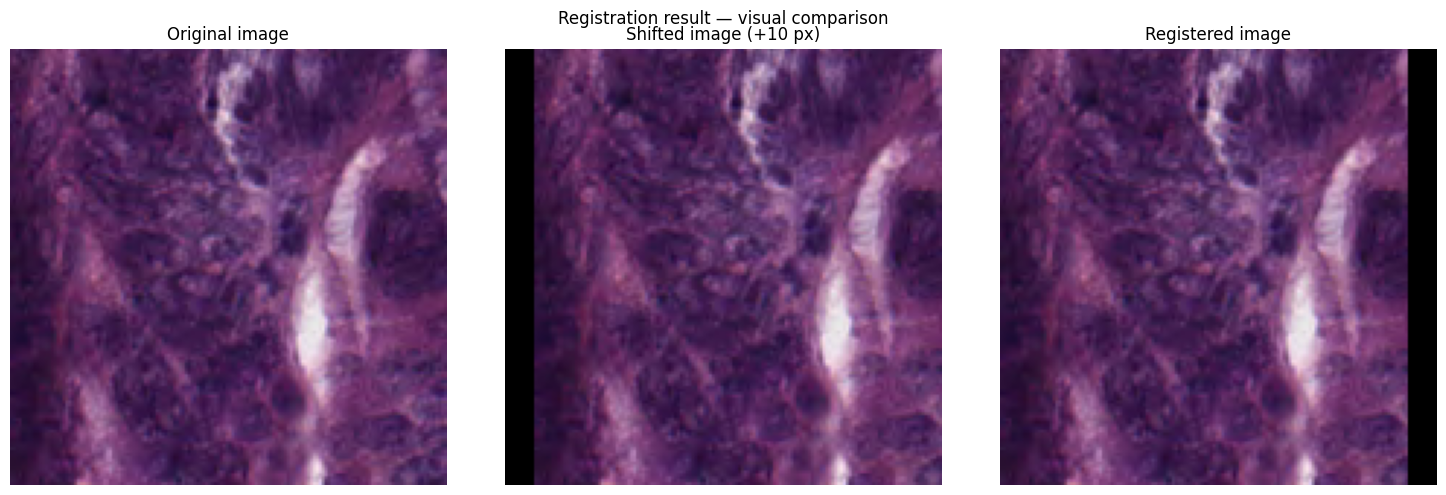

In [11]:
# Apply the detected correction to the shifted image
from scipy.ndimage import shift as apply_shift

# Apply correction shift to recover the original position
registered_image = apply_shift(
    shifted_image,
    shift=[detected_shift[0], detected_shift[1], 0]
)

# Convert to uint8 for display
registered_image = np.clip(registered_image, 0, 255).astype(np.uint8)

# Display original, shifted and registered images side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(shifted_image)
axes[1].set_title(f"Shifted image (+{shift_x} px)")
axes[1].axis("off")

axes[2].imshow(registered_image)
axes[2].set_title("Registered image")
axes[2].axis("off")

plt.suptitle("Registration result — visual comparison")
plt.tight_layout()
plt.show()

### Observations

Applying the detected correction visually restored the original position
of the image. The main tissue structures in the registered image align
with the original. Differences are observed only in the border regions
and are attributed to data loss during the initial shift. The next step
is quantitative assessment of alignment quality using RMSE.

## Step 5 — RMSE

Visual assessment of image alignment is insufficient for a scientifically
grounded result. In geodesy and metrology, every measurement is accompanied
by a quantitative accuracy evaluation. In Project 1, this role is fulfilled
by RMSE — a direct analogue of the root mean square error (RMSE), one of
the primary accuracy metrics in geodesy and metrology.

For each pixel, the difference between the original and registered image
at the same spatial position is calculated. These differences are used to
compute the RMSE, which translates the visual impression of registration
into a quantitative measure of its quality.

In [12]:
# Compute RMSE between original and registered image
import numpy as np

# Convert both images to grayscale by averaging RGB channels
# Registration quality is assessed on spatial structure, not colour
original_gray   = np.mean(image, axis=2)
registered_gray = np.mean(registered_image, axis=2)

# Compute pixel-wise difference between original and registered
difference = original_gray - registered_gray

# Compute RMSE — direct analogue of standard accuracy assessment used in geodesy
rmse = np.sqrt(np.mean(difference ** 2))

print("Registration RMSE:", round(rmse, 4))

Registration RMSE: 20.6897


### Observations

The RMSE between the original and registered images is 20.69 intensity
units. With a value range of 0 to 255, this corresponds to approximately
8% of the full brightness range.

However, this result requires careful interpretation. RMSE provides an
averaged estimate of differences across the entire image and does not
indicate where errors occur. At this stage it is not possible to determine
whether the differences are predominantly associated with border regions
introduced by the spatial transformation, or whether they are also present
in the central area of the image.

To further interpret registration quality, the spatial distribution of
errors needs to be investigated. The next step is to build an error map
that localises the areas of greatest difference between the original and
registered image.

### Error Map

RMSE provides an average measure of errors across the entire image
but does not reveal their spatial distribution. In geodesy, residual
error analysis always includes investigation of their spatial pattern:
where errors concentrate and whether spatial regularities exist.

An error map visualises the difference between the original and
registered image for each pixel individually. This allows identification
of areas of greatest difference and investigation of the spatial
distribution of errors after registration.

At this stage, the error map will be used to examine where the main
differences between the images are localised and whether they are
predominantly associated with border regions or are also present in
the tissue overlap zone.

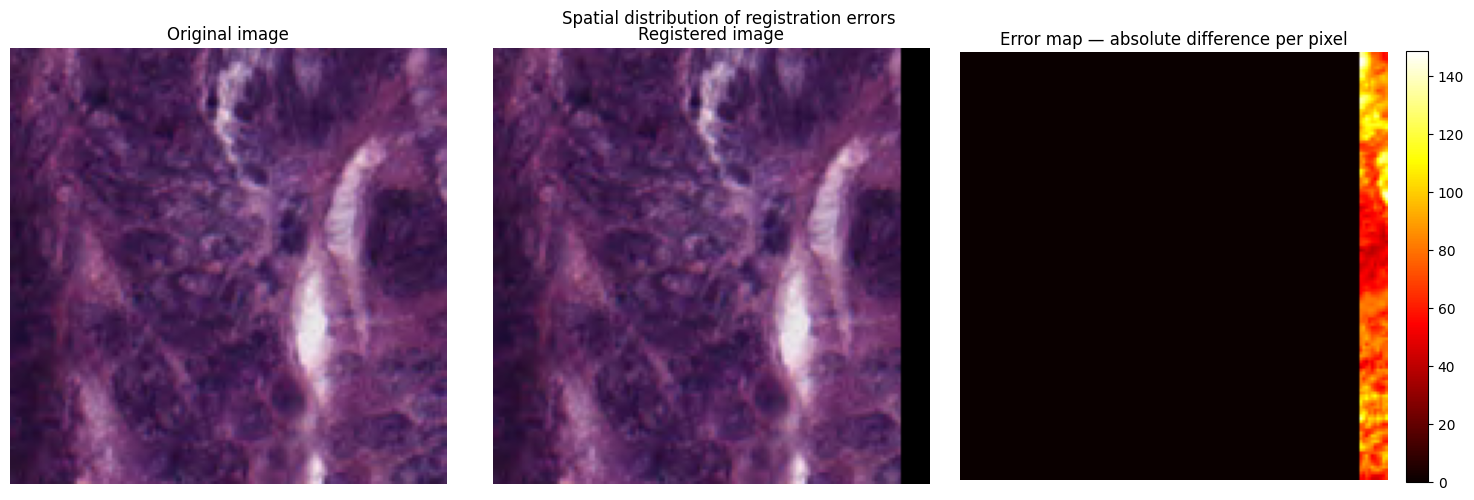

Min error:      0.0
Max error:      148.6667
Mean error:     5.1713
Std of errors:  20.033
RMSE:           20.6897


In [13]:
# Compute and visualise the spatial distribution of registration errors
import matplotlib.pyplot as plt
import numpy as np

# Compute pixel-wise absolute difference between original and registered
error_map = np.abs(original_gray - registered_gray)

# Display error map
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(registered_image)
axes[1].set_title("Registered image")
axes[1].axis("off")

axes[2].imshow(error_map, cmap='hot')
axes[2].set_title("Error map — absolute difference per pixel")
axes[2].axis("off")

plt.colorbar(axes[2].images[0], ax=axes[2], fraction=0.046, pad=0.04)
plt.suptitle("Spatial distribution of registration errors")
plt.tight_layout()
plt.show()

# Basic statistics of error map
print("Min error:     ", round(error_map.min(), 4))
print("Max error:     ", round(error_map.max(), 4))
print("Mean error:    ", round(error_map.mean(), 4))
print("Std of errors: ", round(error_map.std(), 4))
print("RMSE:          ", round(rmse, 4))

### Observations

The error map revealed pronounced spatial heterogeneity in registration
errors. The central area of the image shows minimal errors close to zero,
indicating good alignment of the main tissue region. The largest errors
are concentrated in the right border area of the image, associated with
data loss after the spatial transformation.

This result explains the high RMSE value of 20.69 alongside the
relatively low mean error of 5.17. The large standard deviation of
errors (Std = 20.03) confirms their non-uniform distribution: most pixels
show small errors, while a limited border region contains substantially
larger deviations.

The main contribution to the overall RMSE therefore comes not from the
entire image area but from a localised region at the boundary. This
indicates that the differences between the original and registered images
are predominantly attributable to border effects rather than systematic
registration errors across the tissue.

### Control Point Validation

In geodesy and photogrammetry, solution quality is assessed not only
through overall error statistics but also through individual control
points. This approach allows verification of specific object alignment
and identification of local issues that may be hidden behind averaged
metrics.

In this exercise, we manually define several control points on the image
and assess registration error at specific spatial positions. This is a
simplified demonstration of the control point principle, aimed at
comparing local quality assessment with global metrics such as RMSE
and the error map.

Point    Position          Original   Registered    Error
----------------------------------------------------------
1        (30, 30)           63.33        63.33     0.00
2        (30, 110)           83.33        83.33     0.00
3        (75, 75)           98.67        98.67     0.00
4        (120, 30)          129.00       129.00     0.00
5        (120, 110)          124.00       124.00     0.00
----------------------------------------------------------
Mean error at control points:                0.00
Global RMSE:                              20.6897
Global Mean error:                         5.1713


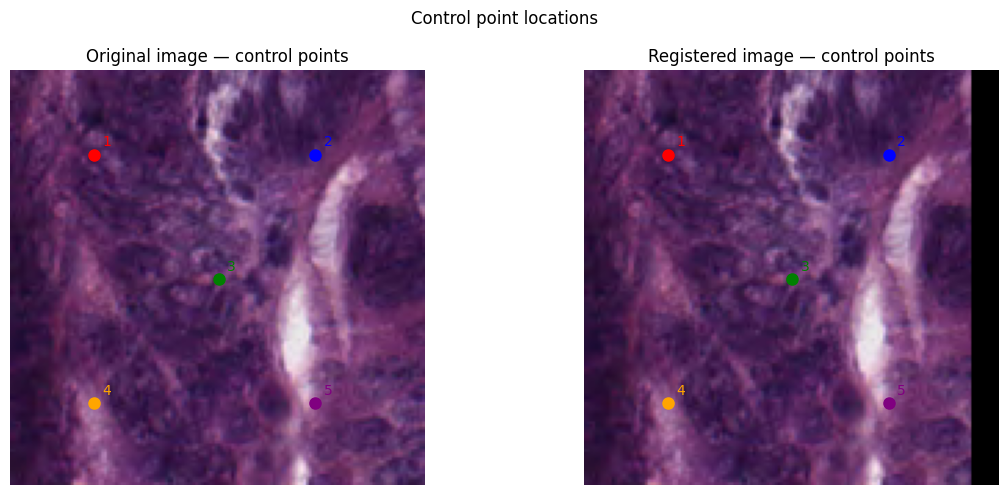

In [14]:
# Supplementary exercise — landmark-based quality check
# Control points are manually defined following photogrammetric principles:
# spatial distribution across the image, avoiding border regions
import numpy as np
import matplotlib.pyplot as plt

# Define control points as (row, column) coordinates
# Selected to cover different spatial zones of the image
control_points = [
    (30, 30),    # upper left quadrant
    (30, 110),   # upper right quadrant
    (75, 75),    # centre
    (120, 30),   # lower left quadrant
    (120, 110)   # lower right quadrant
]

# Compute error at each control point
# Error = absolute difference in pixel intensity at the same position
print(f"{'Point':<8} {'Position':<15} {'Original':>10} {'Registered':>12} {'Error':>8}")
print("-" * 58)

errors = []
for i, (row, col) in enumerate(control_points):
    original_val   = original_gray[row, col]
    registered_val = registered_gray[row, col]
    error = abs(original_val - registered_val)
    errors.append(error)
    print(f"{i+1:<8} ({row}, {col}){'':>5} {original_val:>10.2f} {registered_val:>12.2f} {error:>8.2f}")

print("-" * 58)
print(f"{'Mean error at control points:':<40} {np.mean(errors):>8.2f}")
print(f"{'Global RMSE:':<40} {rmse:>8.4f}")
print(f"{'Global Mean error:':<40} {error_map.mean():>8.4f}")

# Visualise control points on the image
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title("Original image — control points")
axes[0].axis("off")

axes[1].imshow(registered_image)
axes[1].set_title("Registered image — control points")
axes[1].axis("off")

# Mark control points on both images
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, (row, col) in enumerate(control_points):
    for ax in axes:
        ax.plot(col, row, 'o', color=colors[i], markersize=8)
        ax.text(col+3, row-3, str(i+1), color=colors[i], fontsize=10)

plt.suptitle("Control point locations")
plt.tight_layout()
plt.show()

### Observations

Quality assessment at five control points located in the central area
of the image showed zero error at all selected positions. This confirms
that registration in the main tissue overlap zone was performed correctly
and key local structures were aligned without notable deviation.

Comparison with global quality metrics (RMSE = 20.69, Mean error = 5.17)
indicates that the high overall error is predominantly caused by border
regions affected by data loss after the spatial transformation. In the
central tissue area, alignment quality is substantially better than the
single RMSE value might suggest.

This experiment demonstrates the distinction between global and local
registration quality assessment. Global metrics describe alignment quality
across the entire image, while control points allow verification of
alignment at specific spatial positions. In real Spatial Biology tasks,
this approach can be used to assess registration quality for biologically
relevant objects such as cells, nuclei or tissue boundaries.

### Observations — Biological Consequences

Registration errors have direct consequences for the biological
interpretation of data. Inaccurate image alignment can distort spatial
relationships between tissue structures, potentially leading to false
conclusions about cell positioning, interactions and tissue organisation.

In this experiment, the error map showed that the main differences are
localised in the border region of the image and are associated with data
loss after the spatial transformation. The central tissue area demonstrated
minimal errors, and control points in the overlap zone showed zero
deviation. This allows spatial relationships in the central image area
to be considered reliable for further analysis.

An important outcome of this stage was the understanding that the
acceptability of an error is determined not only by its magnitude but
also by the biological task. The same error may be acceptable for
analysing large tissue structures while being unacceptable for analysing
individual cells. Registration quality should therefore be assessed not
only by numerical metrics but also by their impact on the final biological
conclusion.

Registration is thus not merely a technical image processing step but
a fundamental part of ensuring the reliability of spatial biological
analysis.

## Step 6 — Nature of Errors

Following the computation of RMSE, the error map and the landmark-based quality check, the next stage is to examine the nature of the observed errors. The previous steps established the magnitude of errors and their spatial distribution. The question now is whether the detected errors are random or systematic.

In this step, we use the results of the error map to characterise the nature of the observed deviations and to test the hypothesis of a systematic border effect following the spatial transformation of the image.


In [15]:
# Step 6 — Analyse the nature of registration errors

# Compare error levels in the central region and at the right edge

height, width = error_map.shape

# Central part of the image
center_region = error_map[:, 30:120]

# Right edge where border artefacts were observed
right_edge = error_map[:, 140:]

print("Analysis of error distribution")
print("-" * 40)

print("Mean error (center region): ", round(center_region.mean(), 4))
print("Mean error (right edge):    ", round(right_edge.mean(), 4))

Analysis of error distribution
----------------------------------------
Mean error (center region):  0.0
Mean error (right edge):     77.5698


### Observations — Nature of Errors

Quantitative comparison of errors in the central zone and at the right
border of the image confirmed the hypothesis of a systematic border
effect. The mean error in the central part of the image was 0.0 — within
the metric used, no errors were detected in the tissue overlap zone.
The mean error in the right border zone was 77.57 intensity units,
corresponding to approximately 30% of the full brightness range.

The results confirm the findings of the error map and demonstrate
pronounced spatial heterogeneity in registration errors. The error is
localised in a specific area of the image and is not distributed
randomly across the tissue. This indicates its predominantly systematic
character.

The observed error pattern is consistent with data loss in the border zone following the spatial transformation of the image. Consequently, the main contribution to the overall registration error comes from a systematic border effect rather than random noise distributed across the entire image.

## Step 7 — Validation

Within Project 1, the controlled shift of 10 pixels served as the first reference validation. The algorithm successfully recovered the known displacement, confirming the fundamental operability of the registration method. However, one successful test is insufficient to assess pipeline reliability.

Three additional tests were performed to evaluate robustness under varying conditions: Test 1 — Zero shift: does the algorithm detect displacement when there is none? Test 2 — Different shift: does the method work for other displacement values? Test 3 — Noise: does the method remain functional on non-ideal data?

### Test 1 — Null Case

The first additional test examines the algorithm's behaviour in the null case — when the images are already aligned and no displacement exists between them. The purpose of the test is to verify that the method does not detect displacement where none is present.

Both images are identical. The expected registration result is therefore a displacement of [0, 0]. A non-zero detected value would indicate false detections and insufficient method reliability.

In [16]:
# Test 1 — Null case
# Verify that the algorithm detects no displacement when images are identical

from skimage.registration import phase_cross_correlation
import numpy as np

original_gray = np.mean(image, axis=2)

detected_shift_null, error_null, _ = phase_cross_correlation(
    original_gray,
    original_gray
)

print("Test 1 — Null Case")
print("-" * 40)
print("Expected displacement: [0, 0]")
print("Detected displacement:", detected_shift_null)

Test 1 — Null Case
----------------------------------------
Expected displacement: [0, 0]
Detected displacement: [0. 0.]


### Observations — Test 1 (Null Case)

The first validation test examined the algorithm's behaviour in the null
case — when no displacement exists between the images. The expected
result was a displacement of [0, 0], since two identical images were
used for registration.

The algorithm correctly identified the absence of displacement and
returned [0.0, 0.0]. This confirms that the method does not produce
false detections and does not identify displacement where none exists.

From a metrological perspective, this test corresponds to a zero reading
verification. When the measured quantity is absent, the measurement result
should also be zero. The obtained result confirms the correct behaviour
of the algorithm in the baseline scenario and provides additional evidence
for the reliability of the registration pipeline.

### Test 2 — Different Displacement

The second test examines whether the algorithm works for a different
displacement value. The reference validation used a shift of 10 pixels.
This test uses a shift of 20 pixels.

If the algorithm correctly recovers this displacement as well, it
demonstrates that the method is not limited to one specific value but
is capable of detecting different displacement magnitudes.

The purpose of the test is to verify method robustness when the magnitude
of the spatial transformation is changed.

In [17]:
# Test 2 — Different displacement
# Verify that the algorithm works for a displacement value other than 10 pixels

import numpy as np
from skimage.registration import phase_cross_correlation

# Apply a shift of 20 pixels to the right
shift_test2 = 20
shifted_test2 = np.zeros_like(image)
shifted_test2[:, shift_test2:, :] = image[:, :-shift_test2, :]

# Convert to grayscale
original_gray = np.mean(image, axis=2)
shifted_test2_gray = np.mean(shifted_test2, axis=2)

# Run registration
detected_shift_test2, _, _ = phase_cross_correlation(
    original_gray,
    shifted_test2_gray
)

print("Test 2 — Different Displacement")
print("-" * 40)
print(f"Applied shift:       [0, {shift_test2}]")
print(f"Expected correction: [0, {-shift_test2}]")
print("Detected correction:", detected_shift_test2)

Test 2 — Different Displacement
----------------------------------------
Applied shift:       [0, 20]
Expected correction: [0, -20]
Detected correction: [  0. -20.]


### Observations — Test 2 (Different Displacement)

The algorithm correctly identified the correction [0, -20] for a shift
of 20 pixels. The result fully matches the expected value. This confirms
that the method works not only for the specific displacement value used
in the reference validation but also for other spatial transformation
magnitudes.

The ability of the algorithm to maintain correct performance when the
displacement magnitude changes is an important condition for its
applicability in real tasks where the offset between images is not known
in advance.

### Test 3 — Noise

The third test examines the algorithm's robustness to noise. Biological images often contain noise from acquisition, staining or illumination conditions. The previous tests were performed on idealised data without additional noise.

In this experiment, synthetic random noise is added to the image before registration. The purpose of the test is to verify whether the algorithm retains the ability to correctly determine displacement under one simple noise condition.

Test 3 — Noise
----------------------------------------
Applied shift:       [0, 10]
Expected correction: [0, -10]
Detected correction: [  0. -10.]
Noise level:         20 intensity units


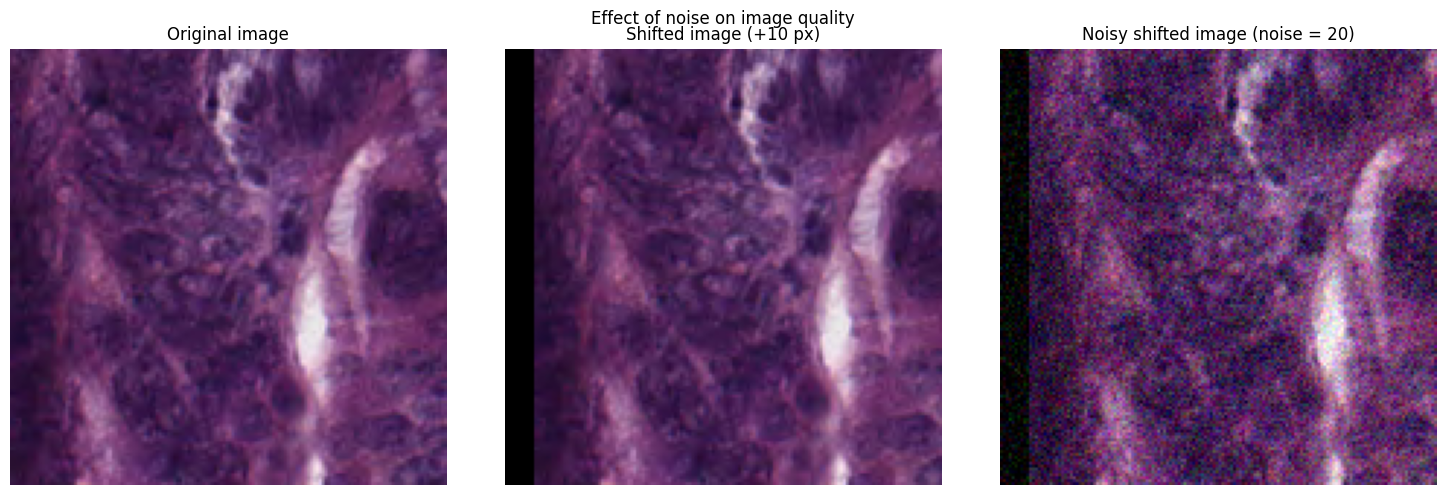

In [18]:
# Test 3 — Noise
# Verify that the algorithm remains functional on non-ideal data

import numpy as np
from skimage.registration import phase_cross_correlation

# Apply the same shift as in the reference validation
shift_test3 = 10
shifted_test3 = np.zeros_like(image)
shifted_test3[:, shift_test3:, :] = image[:, :-shift_test3, :]

# Add random noise to the shifted image
# seed(42) ensures reproducibility — same noise on every run
np.random.seed(42)

noise_level = 20
noisy_shifted = shifted_test3 + np.random.normal(
    0,
    noise_level,
    shifted_test3.shape
)
noisy_shifted = np.clip(noisy_shifted, 0, 255).astype(np.uint8)

# Convert to grayscale
original_gray = np.mean(image, axis=2)
noisy_gray    = np.mean(noisy_shifted, axis=2)

# Run registration
detected_shift_test3, _, _ = phase_cross_correlation(
    original_gray,
    noisy_gray
)

print("Test 3 — Noise")
print("-" * 40)
print(f"Applied shift:       [0, {shift_test3}]")
print(f"Expected correction: [0, {-shift_test3}]")
print("Detected correction:", detected_shift_test3)
print(f"Noise level:         {noise_level} intensity units")

# Visualise the effect of noise on image quality
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(shifted_test3)
axes[1].set_title(f"Shifted image (+{shift_test3} px)")
axes[1].axis("off")

axes[2].imshow(noisy_shifted)
axes[2].set_title(f"Noisy shifted image (noise = {noise_level})")
axes[2].axis("off")

plt.suptitle("Effect of noise on image quality")
plt.tight_layout()
plt.show()


### Observations — Test 3 (Noise)

The algorithm correctly identified the correction [0, -10] in the
presence of random noise at a level of 20 intensity units. The result
fully matches the expected value. This confirms that the method retains
functionality on non-ideal data at a moderate noise level.

The noise test showed that the method remained functional under one simple synthetic noise condition. Robustness at higher noise levels and other types of image degradation requires separate investigation.

### Validation Summary

The extended validation included three additional tests. The null case showed that the algorithm does not detect displacement where none exists. The test with a different displacement value indicated that the method works not only for one specific value but also for various spatial transformation magnitudes. The noise test supported the conclusion that the algorithm retains functionality under one simple synthetic noise condition.

The combined results of the reference and extended validation increase confidence in the registration pipeline and support its correctness, robustness and applicability within the tested conditions.

### Interpretation

The results demonstrate that a global registration quality metric can
be misleading when considered without spatial context. An RMSE of 20.69
appears at first glance to indicate a significant alignment error.
However, spatial analysis shows that this value is attributable not to
the quality of tissue registration but to a border effect — a predictable
and reproducible consequence of the spatial transformation.

In the central zone, where the main tissue area is located, the mean
error was 0.0 and control points showed zero deviation at all positions.
This means that spatial relationships between tissue structures in the
overlap zone are correctly preserved and can serve as a reliable basis
for subsequent spatial analysis.

The systematic nature of the error is an important finding. Unlike random
noise, a systematic error is predictable: its source is known, its
localisation is known, and it does not extend across the entire image
area. This makes it possible to separate the problematic region from the
reliable part of the data and assess them independently.



### Decision

Based on the combined results, the registered data can be used for
subsequent spatial biological analysis, however their reliability
varies across different image regions.

The central tissue zone shows no measurable registration errors within
the metrics used. The mean error in this region was 0.0 and control
points showed complete alignment. This indicates that spatial
relationships between tissue structures in the overlap zone are correctly
preserved and can be used for further analysis.

The right border region is characterised by high error values caused by
a systematic border effect arising from data loss after the spatial
transformation. Since the source of the error is known and localised,
this region should be excluded from subsequent interpretation or treated
with particular caution.

Validation supported the correctness, robustness and reproducibility of the pipeline within the tested conditions. However, the conclusions
apply only to the investigated transformation type, the image used and
the tested noise levels. For broader applicability, additional validation
on other images, noise levels and types of spatial transformations is
recommended.

### Final Interpretation

The main conclusion of the project is that the decision on data
suitability should be based on a body of evidence rather than any single
quality metric.

The next step is to present the project as a reproducible public
repository.